<a href="https://colab.research.google.com/github/trady910605-star/RFM_Analysis_My/blob/main/RFM_Analysis_My.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First Title  
## Second Title  
- item 1
- item 2
- item 3
**abcde**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df=pd.read_csv("RFM_Raw.csv")
df.head()

,Date,InvoNo,CustomerKey,Amount
0,2018/1/1,JA1803995,A0620,411.400
1,2018/1/1,JA1805774,A1336,658.240
2,2018/1/1,JA1801197,A0786,1892.352
3,2018/1/2,JA1805224,A0937,411.400
4,2018/1/2,JA1802973,A1371,411.400


In [17]:
import pandas as pd

# 假設你的原始資料長這樣：
# data = {
#     'CustomerKey': ['C001', 'C001', 'C002', 'C002', 'C002'],
#     'Date': ['2026-05-01', '2026-05-10', '2026-05-03', '2026-05-15', '2026-05-20'],
#     'InvoNo': ['INV001', 'INV002', 'INV003', 'INV004', 'INV005'],
#     'Amount': [100, 200, 150, 300, 50],
# }
# df = pd.DataFrame(data)

# 1. 確保「Date」欄位是 datetime 型態，以便後續做Date減法
df['Date'] = pd.to_datetime(df['Date'])

# 2. 找出整個資料集中的「最大Date」作為基準點
max_date = df['Date'].max()

# 3. 進行 groupby 並計算 F、M、R
rfm_df = (
    df.groupby('CustomerKey')
    .agg(
        # F: InvoNo計數（通常用 count 或 nunique，這裡依需求用 count）
        F=('InvoNo', 'count'),
        # M: Amount加總
        M=('Amount', 'sum'),
        # 先找出該客戶的最大交易Date，用來算 R
        max_transaction_date=('Date', 'max'),
    )
    .reset_index()
)

# 4. 計算 R：基準最大Date 與 該客戶最大交易Date 的差額
# .dt.days 可以將時間差轉換成整數的天數
rfm_df['R'] = (max_date - rfm_df['max_transaction_date']).dt.days

# 5. 調整欄位名稱與順序，符合你的要求：Customer, F, M, R
rfm_df = rfm_df.rename(columns={'CustomerKey': 'Customer'})

# 移除中途幫忙計算而暫存的 max_transaction_date 欄位，並只保留需要的四個欄位
rfm_df = rfm_df[['Customer', 'F', 'M', 'R']]

# 檢視結果
print(rfm_df)

    Customer   F            M   R
0      A0350  25  51238.11440   9
1      A0351   6  17890.31200  16
2      A0352  14  46424.03852  14
3      A0353  14  27607.68636  24
4      A0354   6   9973.92064  31
..       ...  ..          ...  ..
727    A1413  23  52738.79456  10
728    A1415  20  53019.49664  17
729    A1416  24  49938.38378   4
730    A1419  22  64257.84520  50
731    A1420  14  25054.18342  85

[732 rows x 4 columns]


In [18]:
rfm_df.to_csv("RFM_Data.csv",index = False)

In [19]:
import pandas as pd

# 1. 載入原始資料並進行 RFM 計算
df = pd.read_csv('RFM_Raw.csv')
df['Date'] = pd.to_datetime(df['Date'])
max_date = df['Date'].max()

rfm_df = (
    df.groupby('CustomerKey')
    .agg(
        F=('InvoNo', 'count'),
        M=('Amount', 'sum'),
        max_transaction_date=('Date', 'max'),
    )
    .reset_index()
)

rfm_df['R'] = (max_date - rfm_df['max_transaction_date']).dt.days
rfm_df = rfm_df.rename(columns={'CustomerKey': 'Customer'})
rfm_df = rfm_df[['Customer', 'F', 'M', 'R']]

# 2. 儲存為 RFM_Data.csv
rfm_df.to_csv('RFM_Data.csv', index=False)

# 3. 重新載入 RFM_Data.csv 並顯示前五筆
rfm_data = pd.read_csv('RFM_Data.csv')
rfm_data.head()

,Customer,F,M,R
0,A0350,25,51238.11440,9
1,A0351,6,17890.31200,16
2,A0352,14,46424.03852,14
3,A0353,14,27607.68636,24
4,A0354,6,9973.92064,31


In [20]:
from sklearn.preprocessing import MinMaxScaler

# 複製一份 RFM 資料做正規化
nrfm = rfm_data.copy()

# 宣告 MinMaxScaler
scaler = MinMaxScaler()

# 對 R, F, M 欄位進行正規化 (縮放到 0~1)
nrfm[['R', 'F', 'M']] = scaler.fit_transform(nrfm[['R', 'F', 'M']])

# 顯示正規化後的結果
display(nrfm.head())

,Customer,F,M,R
0,A0350,0.631579,0.376563,0.024523
1,A0351,0.131579,0.127866,0.043597
2,A0352,0.342105,0.340662,0.038147
3,A0353,0.342105,0.200335,0.065395
4,A0354,0.131579,0.068827,0.084469


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak o

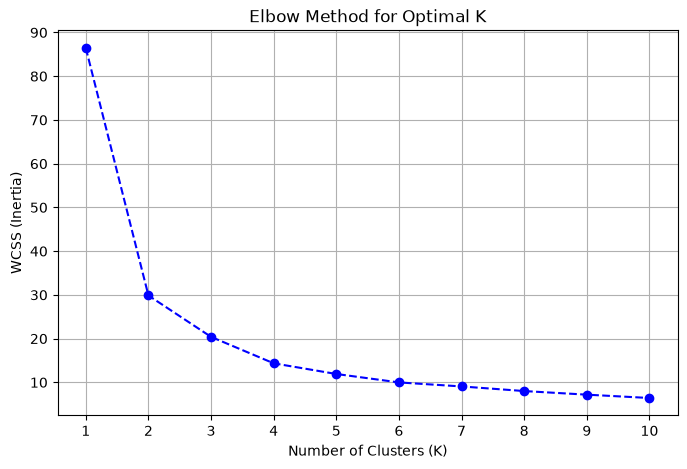

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 提取正規化後的特徵值
features = nrfm[['R', 'F', 'M']]

# 計算不同群數下的 WCSS (inertia)
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

# 繪製手肘法圖表
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [22]:
from sklearn.cluster import KMeans

# 1. 建立 KMeans 模型並設定群數為 4
k=4
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

# 2. 進行分群預測並將標籤加入原資料集與正規化資料集
rfm_features = nrfm[['R', 'F', 'M']]
cluster_labels = kmeans.fit_predict(rfm_features)

nrfm['Cluster'] = cluster_labels
rfm_data['Cluster'] = cluster_labels

# 3. 計算每一群的資料筆數
print("各群客戶數量分佈：")
print(rfm_data['Cluster'].value_counts().sort_index())

# 4. 顯示分群後的部分資料
display(rfm_data.head())

各群客戶數量分佈：
Cluster
0     75
1    131
2    212
3    314
Name: count, dtype: int64


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,Customer,F,M,R,Cluster
0,A0350,25,51238.11440,9,1
1,A0351,6,17890.31200,16,3
2,A0352,14,46424.03852,14,2
3,A0353,14,27607.68636,24,2
4,A0354,6,9973.92064,31,3


In [37]:
rfm_data

,Customer,F,M,R,Cluster,Group
0,A0350,25,51238.11440,9,1,High
1,A0351,6,17890.31200,16,3,Medium
2,A0352,14,46424.03852,14,2,Low
3,A0353,14,27607.68636,24,2,Low
4,A0354,6,9973.92064,31,3,Medium
...,...,...,...,...,...,...
727,A1413,23,52738.79456,10,2,Low
728,A1415,20,53019.49664,17,2,Low
729,A1416,24,49938.38378,4,2,Low
730,A1419,22,64257.84520,50,1,High


In [39]:
# 載入 Silhouette 套件，為驗證分組成效，需要執行 Silhouette 分析
from sklearn.metrics import silhouette_samples
silhouette=silhouette_samples(rfm_data[["R","F","M"]], rfm_data.Cluster)

C:\Users\student\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
C:\Users\student\anaconda3\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 0, 'Item No')

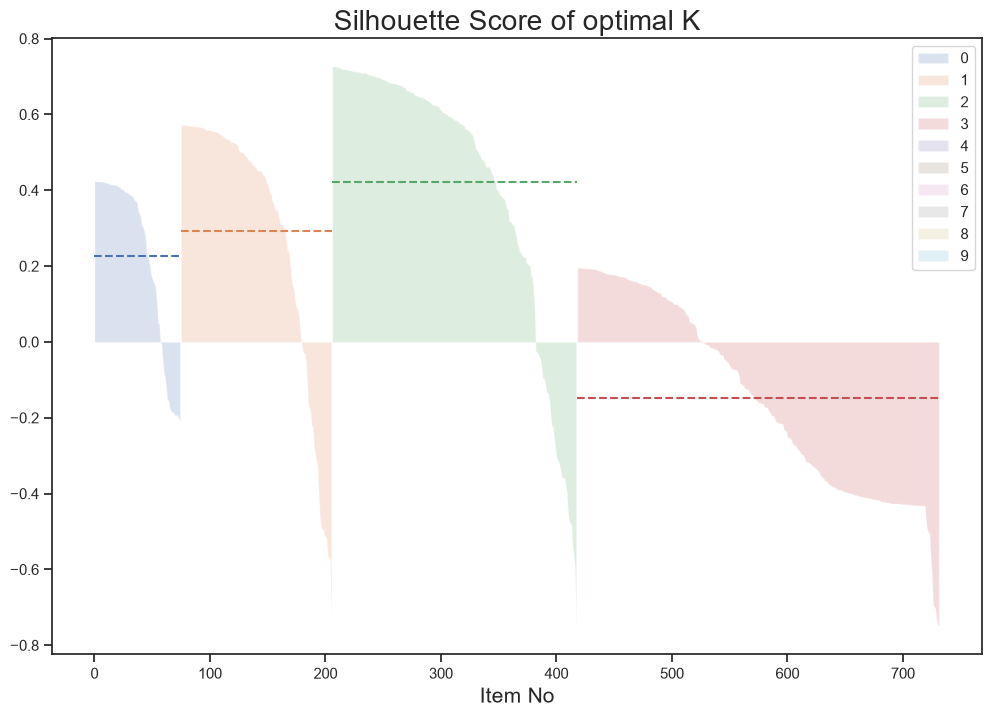

In [41]:
# 01 設定畫布尺寸
# 02 初始類別軸起始點
# 03 繪製 Silhouette 圖

#承繼前段 k-means 分組數
plt.figure(figsize=[12,8]) #01
x0=0 #02

#03
for i in range(k):
   
    group_slh=silhouette[rfm_data.Cluster==i] # 取出 i 組 silhouette 分數表
    x=range(x0,x0+len(group_slh)) # 以 i 組序列範圍為類別軸 (x)

    y=-np.sort(-group_slh) # 將 i 組 silhouette 分數表依遞減排序，為數值軸 (y)
    yavg=np.average(group_slh) # 計算 i 組 silhouette 分數平均值，為數值軸參考線

    plt.fill_between(x,y,alpha=0.2,label=i) # 繪圖區填滿
 
    plt.plot([x0,x0+len(group_slh)],[yavg,yavg],'--') # 標註平均線
   
    plt.legend() # 繪製圖例
       
    x0=x0+len(group_slh) # 設定次組類別軸起始點

plt.title('Silhouette Score of optimal K',fontsize=20)
plt.xlabel('Item No',fontsize=15)

In [34]:
kmeans.labels_

array([1, 3, 2, 2, 3, 3, 3, 2, 3, 3, 0, 3, 2, 3, 2, 2, 3, 1, 0, 1, 0, 2,
       2, 3, 2, 2, 3, 3, 3, 3, 3, 2, 0, 2, 3, 3, 3, 1, 3, 3, 2, 1, 2, 2,
       0, 3, 2, 3, 3, 1, 3, 0, 3, 2, 1, 1, 2, 0, 3, 0, 3, 2, 2, 3, 3, 2,
       1, 3, 3, 2, 0, 3, 3, 3, 2, 2, 2, 0, 1, 2, 1, 3, 3, 2, 2, 2, 2, 3,
       3, 3, 2, 3, 3, 3, 3, 3, 1, 3, 2, 2, 2, 3, 3, 3, 3, 2, 2, 2, 2, 3,
       3, 3, 2, 1, 2, 2, 3, 2, 2, 3, 2, 3, 3, 2, 1, 2, 1, 2, 3, 3, 3, 2,
       3, 3, 0, 1, 1, 0, 2, 3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 1, 3, 2,
       1, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 2, 3, 1, 0, 1, 3, 2,
       1, 3, 0, 3, 3, 0, 2, 1, 1, 1, 2, 3, 3, 3, 3, 1, 3, 2, 0, 3, 0, 0,
       1, 2, 2, 1, 3, 3, 2, 0, 3, 2, 3, 0, 1, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       1, 3, 2, 2, 3, 2, 3, 2, 2, 3, 3, 2, 1, 3, 3, 3, 3, 1, 3, 1, 3, 0,
       2, 2, 3, 3, 0, 0, 1, 3, 0, 0, 2, 3, 0, 3, 1, 1, 2, 2, 3, 2, 2, 3,
       1, 3, 3, 3, 2, 1, 2, 1, 1, 3, 3, 3, 0, 2, 3, 2, 2, 3, 3, 3, 1, 3,
       3, 2, 3, 3, 3, 3, 2, 2, 2, 3, 2, 2, 1, 2, 1,

In [23]:
# 計算各群在 R, F, M 上的平均值，以理解各群特徵
cluster_summary = rfm_data.groupby('Cluster').agg(
    客戶數量=('Customer', 'count'),
    R_平均值=('R', 'mean'),
    F_平均值=('F', 'mean'),
    M_平均值=('M', 'mean')
).reset_index()

display(cluster_summary)

,Cluster,客戶數量,R_平均值,F_平均值,M_平均值
0,0,75,183.653333,3.640000,8586.611298
1,1,131,14.786260,26.015267,74066.827784
2,2,212,18.429245,18.636792,44033.340535
3,3,314,45.245223,5.570064,13517.754440


In [24]:
# 建立 Customer 與 Cluster 的對照表
customer_clusters = rfm_data[['Customer', 'Cluster']].rename(columns={'Customer': 'CustomerKey'})

# 將分組標籤合併回原始交易資料 df
df = df.merge(customer_clusters, on='CustomerKey', how='left')

# 顯示合併後的原始資料前五筆
display(df.head())

,Date,InvoNo,CustomerKey,Amount,Cluster
0,2018-01-01,JA1803995,A0620,411.400,0
1,2018-01-01,JA1805774,A1336,658.240,3
2,2018-01-01,JA1801197,A0786,1892.352,3
3,2018-01-02,JA1805224,A0937,411.400,2
4,2018-01-02,JA1802973,A1371,411.400,3


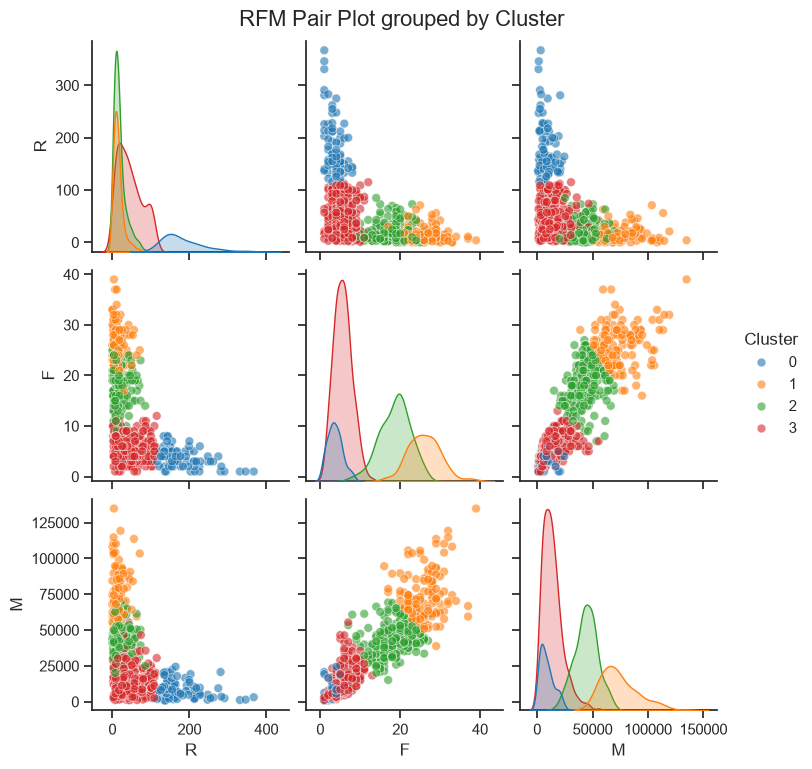

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定繪圖風格與字體中文化（若有需要）
sns.set_theme(style="ticks")

# 繪製 R, F, M 的成對散布圖 (Pair Plot)，以 Cluster 欄位區分顏色 (hue)
# palette 使用 'viridis' 或是其他易辨識的調色盤
g = sns.pairplot(
    rfm_data,
    vars=['R', 'F', 'M'],
    hue='Cluster',
    palette='tab10',
    diag_kind='kde', # 對角線繪製核密度估計圖
    plot_kws={'alpha': 0.6, 's': 40} # 設定散布點的透明度與大小
)

# 設定圖表標題
g.fig.suptitle('RFM Pair Plot grouped by Cluster', y=1.02, fontsize=16)
plt.show()

In [26]:
# 定義 Cluster 與 Group 的對應關係
cluster_mapping = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'Medium'
}

# 新增 Group 欄位並進行對應
df['Group'] = df['Cluster'].map(cluster_mapping)

# 顯示更新後的資料前五筆與欄位資訊
display(df.head())

,Date,InvoNo,CustomerKey,Amount,Cluster,Group
0,2018-01-01,JA1803995,A0620,411.400,0,Missing
1,2018-01-01,JA1805774,A1336,658.240,3,Medium
2,2018-01-01,JA1801197,A0786,1892.352,3,Medium
3,2018-01-02,JA1805224,A0937,411.400,2,Low
4,2018-01-02,JA1802973,A1371,411.400,3,Medium


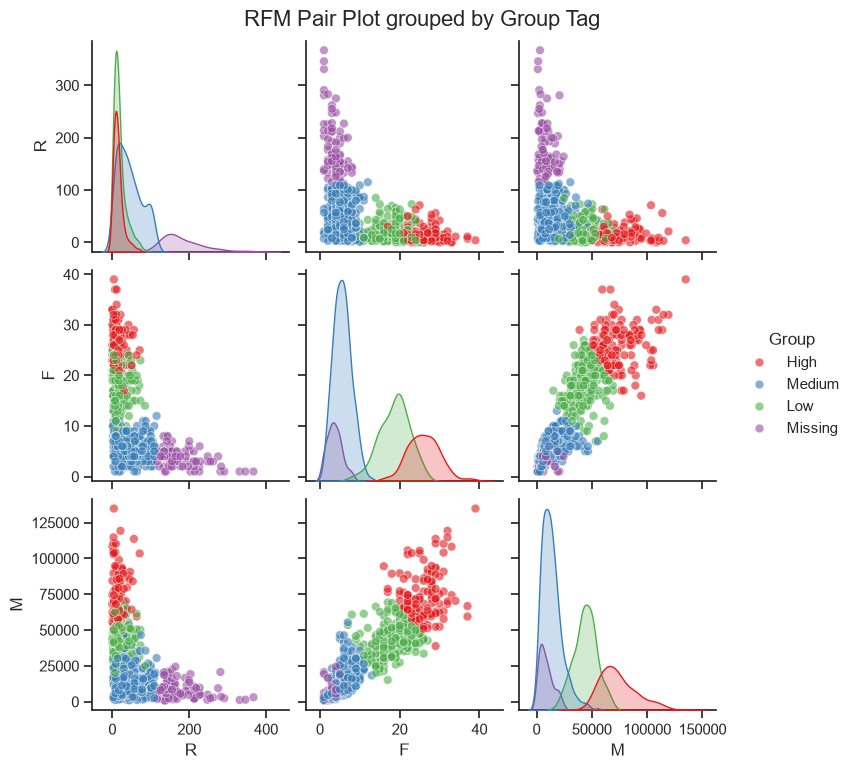

In [27]:
# 將 Group 標籤也同步對應回客戶層級的 rfm_data 中
rfm_data['Group'] = rfm_data['Cluster'].map(cluster_mapping)

# 繪製 R, F, M 散布圖，改以 Group 進行分組與著色
g = sns.pairplot(
    rfm_data,
    vars=['R', 'F', 'M'],
    hue='Group',
    palette='Set1',  # 換一個色彩明亮的調色盤
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

g.fig.suptitle('RFM Pair Plot grouped by Group Tag', y=1.02, fontsize=16)
plt.show()

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 重新繪製 RFM Pair Plot
sns.set_theme(style="ticks")

g = sns.pairplot(
    rfm_data,
    vars=['R', 'F', 'M'],
    hue='Group',
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

g.fig.suptitle(
    'RFM Pair Plot grouped by Group Tag',
    y=1.02,
    fontsize=16
)

# 儲存圖檔
filename = 'RFM_Pairplot.png'

plt.savefig(
    filename,
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.close()

print(f'圖檔已儲存：{filename}')

圖檔已儲存：RFM_Pairplot.png


In [33]:
# 將合併並標記完 Group 的原始交易資料 df 儲存為 CSV
output_filename = 'RFM_result.csv'

df.to_csv(output_filename, index=False)

print(f'檔案已儲存：{output_filename}')


檔案已儲存：RFM_result.csv
